In [ ]:
# Cell 1: Install
!pip install dgl==2.4.0+cu121 -f https://data.dgl.ai/wheels/torch-2.1/cu121/repo.html -q
!pip install git+https://github.com/mims-harvard/TxGNN.git -q

  Preparing metadata (setup.py) ... done


In [ ]:
# Cell 3: Load data
from txgnn import TxData, TxGNN, TxEval
TxData_obj = TxData(data_folder_path='./data')
TxData_obj.prepare_split(split='full_graph', seed=42)

print(f"Node types: {TxData_obj.G.ntypes}")
print(f"Edge types: {len(TxData_obj.G.canonical_etypes)}")

Found local copy...
Found local copy...
Found local copy...
First time usage... Mapping TxData raw KG to directed csv... it takes several minutes...
Iterating over relations...


  0%|          | 0/30 [00:00<?, ?it/s]

Iterating over node types...


  0%|          | 0/10 [00:00<?, ?it/s]

save kg_directed.csv...
Creating splits... it takes several minutes...
split_data_path:  ./data/full_graph_42
Creating DGL graph....
Done!
Node types: ['anatomy', 'biological_process', 'cellular_component', 'disease', 'drug', 'effect/phenotype', 'exposure', 'gene/protein', 'molecular_function', 'pathway']
Edge types: 50


In [ ]:
# Delete processed files so TxGNN reprocesses with full KG
import os, shutil
for f in ['kg_directed.csv', 'full_graph_42']:
    path = os.path.join('./data', f)
    if os.path.isfile(path):
        os.remove(path)
    elif os.path.isdir(path):
        shutil.rmtree(path)
print("Cleaned")

Cleaned


In [ ]:
from txgnn import TxGNN

model = TxGNN(
    data=TxData_obj,
    weight_bias_track=False,
    proj_name='TxGNN',
    exp_name='TxGNN_upper_bound',
    device='cuda:0'
)

model.model_initialize(
    n_hid=512, n_inp=512, n_out=512,
    proto=True, proto_num=3,
    attention=False,
    sim_measure='all_nodes_profile',
    bert_measure='disease_name',
    agg_measure='rarity',
    num_walks=200, walk_mode='bit', path_length=2
)

!mkdir -p /content/model_ckpt
!cp /content/model.pt /content/model_ckpt/
!cp /content/config.pkl /content/model_ckpt/
model.load_pretrained('/content/model_ckpt')
print("Pretrained model loaded!")

Pretrained model loaded!


In [ ]:
# index mismatch, check columns first
kg_dir = pd.read_csv('./data/kg_directed.csv', nrows=5, low_memory=False)
print(kg_dir.columns.tolist())
print(kg_dir.head())

['x_type', 'x_id', 'relation', 'y_type', 'y_id', 'x_idx', 'y_idx']
         x_type    x_id         relation        y_type     y_id    x_idx  \
0  gene/protein  9796.0  protein_protein  gene/protein  56992.0  27422.0   
1  gene/protein  7918.0  protein_protein  gene/protein   9240.0  23886.0   
2  gene/protein  8233.0  protein_protein  gene/protein  23548.0  24822.0   
3  gene/protein  4899.0  protein_protein  gene/protein  11253.0  16773.0   
4  gene/protein  5297.0  protein_protein  gene/protein   8601.0  17769.0   

     y_idx  
0  19536.0  
1  26764.0  
2  10205.0  
3   5880.0  
4  25909.0  


In [ ]:
kg_dir = pd.read_csv('./data/kg_directed.csv', low_memory=False)
diseases = kg_dir[kg_dir['x_type'] == 'disease'][['x_idx', 'x_id']].drop_duplicates()
print(f"TxGNN diseases: {len(diseases)}")
print(f"x_idx range: {diseases['x_idx'].min()} - {diseases['x_idx'].max()}")
print(f"x_id range: {diseases['x_id'].min()} - {diseases['x_id'].max()}")

# Our test IDs are PrimeKG x_index. Check if they match x_id (original PrimeKG IDs)
# In the full kg.csv, x_index maps to x_id
# Let's check: does PrimeKG x_index == TxGNN x_id?
print(f"\nTest ID 27219 in x_id? {27219.0 in diseases['x_id'].values}")
print(f"Test ID 27219 in x_idx? {27219.0 in diseases['x_idx'].values}")

# Our test IDs are x_index from PrimeKG, which should map to x_id here
# since TxGNN loaded the same kg.csv
test_in_txgnn = diseases[diseases['x_id'].isin([float(x) for x in test_ids[:5]])]
print(f"\nFirst 5 test diseases mapped:")
print(test_in_txgnn)

TxGNN diseases: 11114
x_idx range: 0.0 - 17079.0
x_id range: 1.0 - 9999.0

Test ID 27219 in x_id? False
Test ID 27219 in x_idx? False

First 5 test diseases mapped:
Empty DataFrame
Columns: [x_idx, x_id]
Index: []


In [ ]:
import pandas as pd
import numpy as np

kg = pd.read_csv('./data/kg.csv', low_memory=False)
primekg_diseases = kg[kg['x_type'] == 'disease'][['x_index', 'x_id']].drop_duplicates()
primekg_diseases_y = kg[kg['y_type'] == 'disease'][['y_index', 'y_id']].rename(
    columns={'y_index': 'x_index', 'y_id': 'x_id'}).drop_duplicates()
primekg_map = pd.concat([primekg_diseases, primekg_diseases_y]).drop_duplicates('x_index')

test_ids = np.loadtxt('/content/drive/MyDrive/Colab Notebooks/split/test_disease_ids.txt', dtype=int)
test_mapped = primekg_map[primekg_map['x_index'].isin(test_ids)]
print(f"Test diseases mapped: {len(test_mapped)}")
print(test_mapped.head())

kg_dir = pd.read_csv('./data/kg_directed.csv', low_memory=False)
diseases = kg_dir[kg_dir['x_type'] == 'disease'][['x_idx', 'x_id']].drop_duplicates()
txgnn_disease_ids = set(diseases['x_id'].values)
print(f"\nTxGNN disease x_ids: {len(txgnn_disease_ids)}")

matched = 0
for _, row in test_mapped.iterrows():
    mondo_ids = str(row['x_id']).split('_')
    for mid in mondo_ids:
        if float(mid) in txgnn_disease_ids:
            matched += 1
            break
print(f"Test diseases with at least one MONDO in TxGNN: {matched}/{len(test_mapped)}")

Test diseases mapped: 108
         x_index                                               x_id
3084142    27219  7794_9239_9223_13912_13961_7844_13946_14105_13...
3084198    27249                  10615_13006_8250_32569_9876_32567
3084255    27292  9294_13291_10598_13091_10362_9868_9295_9293_92...
3084375    27361  10604_10602_15720_15719_18660_15721_15715_1571...
3084380    27366                              7126_8468_24512_13192

TxGNN disease x_ids: 11114
Test diseases with at least one MONDO in TxGNN: 0/108


In [ ]:
# Compare formats
print("TxGNN disease x_id samples:")
print(sorted(diseases['x_id'].values)[:20])

print("\nPrimeKG MONDO IDs (individual, from test):")
sample_mondos = []
for _, row in test_mapped.head(3).iterrows():
    for mid in str(row['x_id']).split('_'):
        sample_mondos.append(float(mid))
print(sorted(sample_mondos)[:20])

# Check if TxGNN uses different ID scheme
print(f"\nTxGNN x_id min: {diseases['x_id'].min()}, max: {diseases['x_id'].max()}")
print(f"PrimeKG MONDO min: {min(sample_mondos)}, max: {max(sample_mondos)}")

# Also check the original kg.csv disease IDs
orig_diseases = kg[kg['x_type'] == 'disease']['x_id'].unique()
print(f"\nOriginal kg.csv disease x_id samples: {sorted(orig_diseases)[:10]}")
print(f"Original kg.csv disease x_id type: {type(orig_diseases[0])}")

TxGNN disease x_id samples:
['1.0', '1000.0', '100000.0', '100004.0', '100010.0', '100012.0', '100014.0', '10001_19287_23046_23048', '100022.0', '100028.0', '100029.0', '10003.0', '100030.0', '100033.0', '100036.0', '100038.0', '100039.0', '10004.0', '100040.0', '10005.0']

PrimeKG MONDO IDs (individual, from test):
[2412.0, 2413.0, 7794.0, 7844.0, 8250.0, 9223.0, 9239.0, 9290.0, 9291.0, 9293.0, 9294.0, 9295.0, 9482.0, 9868.0, 9876.0, 10362.0, 10598.0, 10615.0, 10635.0, 12528.0]

TxGNN x_id min: 1.0, max: 9999.0
PrimeKG MONDO min: 2412.0, max: 32569.0

Original kg.csv disease x_id samples: ['1', '1000', '10000', '100000', '100001', '100002', '100004', '100005', '100006', '100008']
Original kg.csv disease x_id type: <class 'str'>


In [ ]:
# Both have grouped MONDO IDs - match as strings
# Convert test MONDO IDs to string format matching TxGNN

matched_pairs = []
for _, row in test_mapped.iterrows():
    primekg_id = str(row['x_id'])  # e.g. "7794_9239_9223..."

    for _, txgnn_row in diseases.iterrows():
        txgnn_id = str(txgnn_row['x_id'])  # e.g. "7794.0" or "10001_19287..."

        # Split both into individual IDs and check overlap
        primekg_mondos = set(primekg_id.split('_'))
        txgnn_mondos = set(txgnn_id.replace('.0', '').split('_'))

        if primekg_mondos & txgnn_mondos:
            matched_pairs.append({
                'test_x_index': row['x_index'],
                'primekg_mondo': primekg_id,
                'txgnn_x_idx': txgnn_row['x_idx'],
                'txgnn_x_id': txgnn_id
            })
            break

print(f"Matched: {len(matched_pairs)}/108")
if matched_pairs:
    matched_df = pd.DataFrame(matched_pairs)
    print(matched_df.head(10))

Matched: 108/108
   test_x_index                                      primekg_mondo  \
0         27219  7794_9239_9223_13912_13961_7844_13946_14105_13...   
1         27249                  10615_13006_8250_32569_9876_32567   
2         27292  9294_13291_10598_13091_10362_9868_9295_9293_92...   
3         27361  10604_10602_15720_15719_18660_15721_15715_1571...   
4         27366                              7126_8468_24512_13192   
5         27421                                  100151_9066_18467   
6         27478  8369_11422_9967_8368_15827_17828_1909_18440_17829   
7         27527                                 31332_100326_31009   
8         27610                                               9692   
9         27684                                    9329_20713_9937   

   txgnn_x_idx                                         txgnn_x_id  
0      15171.0  7794_9239_9223_13912_13961_7844_13946_14105_13...  
1        621.0                  10615_13006_8250_32569_9876_32567  
2      1

In [ ]:
# 1. Load TxGNN data as usual
from txgnn import TxData, TxGNN, TxEval

TxData = TxData(data_folder_path='./data')

# 2. Use full_graph split as base, then manually remove
#    test disease indication edges before training
TxData.prepare_split(split='full_graph', seed=42)

# 3. Check what the split object looks like
print(type(TxData.df_train))
print(TxData.df_train.head())
print(TxData.df_train.columns.tolist())

Found local copy...
Found local copy...
Found local copy...
Found saved processed KG... Loading...
Splits detected... Loading splits....
Creating DGL graph....
Done!
<class 'pandas.core.frame.DataFrame'>
         x_type    x_id         relation        y_type     y_id    x_idx  \
0  gene/protein  9796.0  protein_protein  gene/protein  56992.0  27422.0   
1  gene/protein  7918.0  protein_protein  gene/protein   9240.0  23886.0   
2  gene/protein  8233.0  protein_protein  gene/protein  23548.0  24822.0   
3  gene/protein  4899.0  protein_protein  gene/protein  11253.0  16773.0   
4  gene/protein  5297.0  protein_protein  gene/protein   8601.0  17769.0   

     y_idx  
0  19536.0  
1  26764.0  
2  10205.0  
3   5880.0  
4  25909.0  
['x_type', 'x_id', 'relation', 'y_type', 'y_id', 'x_idx', 'y_idx']


In [ ]:
# What diseases were in the original test set?
TxData_check = TxData  # your already-loaded TxData
if hasattr(TxData_check, 'df_test'):
    test_diseases_original = TxData_check.df_test[
        TxData_check.df_test['relation'] == 'indication'
    ]['x_idx'].unique()

    # Compare with your 108
    your_test = set([row['txgnn_x_idx'] for row in matched_pairs])
    overlap = your_test.intersection(set(test_diseases_original))
    print(f"Original test diseases: {len(test_diseases_original)}")
    print(f"Your test diseases: {len(your_test)}")
    print(f"Overlap: {len(overlap)}")
    print(f"Your test diseases that WERE in original training: {len(your_test) - len(overlap)}")
else:
    print("No df_test found — likely full_graph split with no held-out test set")

Original test diseases: 339
Your test diseases: 108
Overlap: 6
Your test diseases that WERE in original training: 102


In [ ]:
# Check metrics on just the 6 properly held-out diseases
import numpy as np

your_test = set([row['txgnn_x_idx'] for row in matched_pairs])
overlap = your_test.intersection(set(test_diseases_original))

# Build a map from txgnn_x_idx to the eval key
# The keys in result['prediction'] encode disease info somehow
# Let's figure out which keys correspond to the 6 overlap diseases

# First, let's check: does matched_pairs have a mapping we can use?
print("matched_pairs[0] keys:", matched_pairs[0].keys())
print()

# Build txgnn_x_idx -> prediction key mapping
# Each disease was evaluated in order of txgnn_test_ids
pred_keys = list(result['prediction'].keys())
print(f"Number of pred keys: {len(pred_keys)}")
print(f"Number of txgnn_test_ids: {len(txgnn_test_ids)}")

# They should be 1:1 in order
overlap_indices = [i for i, tid in enumerate(txgnn_test_ids) if tid in overlap]
print(f"\nOverlap disease indices: {overlap_indices}")
print(f"Their txgnn_x_idx values: {[txgnn_test_ids[i] for i in overlap_indices]}")

# Compute metrics on just these 6
from collections import defaultdict
k_values = [1, 5, 10, 25, 50]
mrrs = []
recalls = defaultdict(list)

for i in overlap_indices:
    key = pred_keys[i]
    scores_dict = result['prediction'][key]
    labels_dict = result['label'][key]

    drug_ids = list(scores_dict.keys())
    scores = np.array([scores_dict[d] for d in drug_ids])
    labels = np.array([labels_dict[d] for d in drug_ids])

    n_pos = int(np.sum(labels == 1))
    if n_pos == 0:
        continue

    ranked_indices = np.argsort(-scores)
    ranked_labels = labels[ranked_indices]

    first_pos = np.where(ranked_labels == 1)[0]
    mrr = 1.0 / (first_pos[0] + 1) if len(first_pos) > 0 else 0.0
    mrrs.append(mrr)

    for k in k_values:
        hits = np.sum(ranked_labels[:k])
        recalls[k].append(hits / n_pos)

    print(f"Disease idx={txgnn_test_ids[i]}: n_pos={n_pos}, MRR={mrr:.4f}, R@10={recalls[10][-1]:.4f}")

print(f"\n=== 6 overlap diseases ===")
print(f"MRR: {np.mean(mrrs):.4f}")
for k in k_values:
    print(f"Recall@{k}: {np.mean(recalls[k]):.4f}")

matched_pairs[0] keys: dict_keys(['test_x_index', 'primekg_mondo', 'txgnn_x_idx', 'txgnn_x_id'])

Number of pred keys: 108
Number of txgnn_test_ids: 108

Overlap disease indices: [23, 26, 35, 49, 99, 101]
Their txgnn_x_idx values: [437.0, 6226.0, 861.0, 1203.0, 1110.0, 1441.0]
Disease idx=437.0: n_pos=1, MRR=0.0002, R@10=0.0000
Disease idx=6226.0: n_pos=17, MRR=0.0002, R@10=0.0000
Disease idx=861.0: n_pos=2, MRR=0.0002, R@10=0.0000
Disease idx=1203.0: n_pos=5, MRR=0.0002, R@10=0.0000
Disease idx=1110.0: n_pos=17, MRR=0.0002, R@10=0.0000
Disease idx=1441.0: n_pos=87, MRR=0.0002, R@10=0.0000

=== 6 overlap diseases ===
MRR: 0.0002
Recall@1: 0.0000
Recall@5: 0.0000
Recall@10: 0.0000
Recall@25: 0.0000
Recall@50: 0.0000


In [ ]:
# Diagnostic: are the label drug IDs and score drug IDs actually aligned?
import numpy as np

# Pick one of the 6 overlap diseases with many positives
key = pred_keys[101]  # idx 1441.0, n_pos=87
scores_dict = result['prediction'][key]
labels_dict = result['label'][key]

# Which drugs are positive?
pos_drugs = [d for d, v in labels_dict.items() if v == 1]
print(f"Number of positive drugs: {len(pos_drugs)}")
print(f"Example positive drug IDs: {pos_drugs[:5]}")

# What scores do positive drugs get?
pos_scores = [scores_dict[d] for d in pos_drugs[:5]]
print(f"Their scores: {pos_scores}")

# What are the TOP scoring drugs?
sorted_drugs = sorted(scores_dict.items(), key=lambda x: x[1], reverse=True)
print(f"\nTop 10 highest-scoring drugs:")
for drug_id, score in sorted_drugs[:10]:
    label = labels_dict[drug_id]
    print(f"  {drug_id}: score={score:.4f}, label={label}")

print(f"\nBottom 10 lowest-scoring drugs:")
for drug_id, score in sorted_drugs[-10:]:
    label = labels_dict[drug_id]
    print(f"  {drug_id}: score={score:.4f}, label={label}")

# Where do positive drugs actually rank?
all_drugs_sorted = [d for d, s in sorted_drugs]
pos_ranks = [all_drugs_sorted.index(d) + 1 for d in pos_drugs[:10]]
print(f"\nRanks of first 10 positive drugs: {pos_ranks}")

Number of positive drugs: 87
Example positive drug IDs: ['DB00145', 'DB00180', 'DB00201', 'DB00283', 'DB00316']
Their scores: [np.float32(-8.104854), np.float32(-7.8793073), np.float32(-9.350133), np.float32(-8.777945), np.float32(-10.124527)]

Top 10 highest-scoring drugs:
  DB02175: score=3.4328, label=0
  DB03614: score=3.0401, label=0
  DB04954: score=2.8546, label=0
  DB06471: score=2.8546, label=0
  DB12569: score=2.8546, label=0
  DB07494: score=2.6202, label=0
  DB08620: score=2.6202, label=0
  DB11421: score=2.6202, label=0
  DB07168: score=2.5722, label=0
  DB08326: score=2.4499, label=0

Bottom 10 lowest-scoring drugs:
  DB00526: score=-14.3760, label=0
  DB11580: score=-14.4086, label=0
  DB01267: score=-14.4435, label=0
  DB00410: score=-14.5458, label=0
  DB00493: score=-14.6515, label=0
  DB00461: score=-14.6517, label=0
  DB01190: score=-14.8277, label=0
  DB06710: score=-15.0707, label=0
  DB01003: score=-15.2461, label=1
  DB00624: score=-15.8645, label=0

Ranks of fi

In [ ]:
# What are the top-scoring drugs? Are they experimental/non-drug entities?
# Check against PrimeKG
import pandas as pd

kg = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/kg.csv')
drug_nodes = kg[kg['x_type'] == 'drug'][['x_index', 'x_id', 'x_name']].drop_duplicates()

# Look up top scorers
top_drugs = ['DB02175', 'DB03614', 'DB04954', 'DB06471', 'DB12569']
pos_examples = ['DB00145', 'DB00180', 'DB00201', 'DB00283', 'DB00316']

print("=== Top-scoring (label=0) ===")
for db_id in top_drugs:
    match = drug_nodes[drug_nodes['x_id'] == db_id]
    if len(match) > 0:
        print(f"  {db_id}: {match.iloc[0]['x_name']}")
    else:
        print(f"  {db_id}: NOT FOUND in PrimeKG")

print("\n=== Positive drugs (label=1, ranked ~7000) ===")
for db_id in pos_examples:
    match = drug_nodes[drug_nodes['x_id'] == db_id]
    if len(match) > 0:
        print(f"  {db_id}: {match.iloc[0]['x_name']}")
    else:
        print(f"  {db_id}: NOT FOUND in PrimeKG")

# Also: how many of the 7957 drugs have ANY indication edge in PrimeKG?
drugs_with_indications = kg[kg['relation'] == 'indication']['x_id'].unique()
print(f"\nDrugs with ≥1 indication in KG: {len(drugs_with_indications)}")
print(f"Total drugs scored: 7957")

# Check how many top-100 scorers have any indication at all
sorted_drugs = sorted(result['prediction'][pred_keys[101]].items(),
                       key=lambda x: x[1], reverse=True)
top100_ids = [d for d, s in sorted_drugs[:100]]
top100_have_indication = sum(1 for d in top100_ids if d in set(drugs_with_indications))
print(f"Top 100 scored drugs that have ANY indication: {top100_have_indication}")

=== Top-scoring (label=0) ===
  DB02175: Malonic acid
  DB03614: Mecobalamin
  DB04954: Tecadenoson
  DB06471: Naxifylline
  DB12569: Tonapofylline

=== Positive drugs (label=1, ranked ~7000) ===
  DB00145: Glycine
  DB00180: Flunisolide
  DB00201: Caffeine
  DB00283: Clemastine
  DB00316: Acetaminophen

Drugs with ≥1 indication in KG: 3164
Total drugs scored: 7957
Top 100 scored drugs that have ANY indication: 0


In [ ]:
import numpy as np

# Filter to drugs with at least 1 indication edge
drugs_with_ind = set(kg[kg['relation'] == 'indication']['x_id'].unique())
print(f"Filtering to {len(drugs_with_ind)} drugs with ≥1 indication")

k_values = [1, 5, 10, 25, 50]
mrrs = []
recalls = {k: [] for k in k_values}
n_pos_list = []

for key in result['prediction']:
    scores_dict = result['prediction'][key]
    labels_dict = result['label'][key]

    # Only keep drugs with at least 1 indication in KG
    drug_ids = [d for d in scores_dict.keys() if d in drugs_with_ind]
    scores = np.array([scores_dict[d] for d in drug_ids])
    labels = np.array([labels_dict[d] for d in drug_ids])

    n_pos = int(np.sum(labels == 1))
    if n_pos == 0:
        continue
    n_pos_list.append(n_pos)

    ranked_indices = np.argsort(-scores)
    ranked_labels = labels[ranked_indices]

    first_pos = np.where(ranked_labels == 1)[0]
    mrrs.append(1.0 / (first_pos[0] + 1) if len(first_pos) > 0 else 0.0)

    for k in k_values:
        hits = np.sum(ranked_labels[:k])
        recalls[k].append(hits / n_pos)

print(f"\nDiseases evaluated: {len(mrrs)}")
print(f"Candidate pool per disease: {len(drugs_with_ind)}")
print(f"Avg positives: {np.mean(n_pos_list):.1f}")
print(f"\n{'Metric':<15} {'Mean':>8} {'Median':>8}")
print("-" * 34)
print(f"{'MRR':<15} {np.mean(mrrs):>8.4f} {np.median(mrrs):>8.4f}")
for k in k_values:
    print(f"{'Recall@'+str(k):<15} {np.mean(recalls[k]):>8.4f} {np.median(recalls[k]):>8.4f}")

Filtering to 3164 drugs with ≥1 indication

Diseases evaluated: 108
Candidate pool per disease: 3164
Avg positives: 7.3

Metric              Mean   Median
----------------------------------
MRR               0.0308   0.0078
Recall@1          0.0093   0.0000
Recall@5          0.0207   0.0000
Recall@10         0.0279   0.0000
Recall@25         0.0840   0.0000
Recall@50         0.1239   0.0000


In [ ]:
# 1. What's in your split directory?
import os
split_dir = '/content/drive/MyDrive/Colab Notebooks/split/'
print("Files in split dir:")
for f in sorted(os.listdir(split_dir)):
    print(f"  {f}")

# 2. How does TxGNN create its internal split?
# Check the format of df_train
print("\n=== df_train format ===")
print(model.df_train.columns.tolist())
print(model.df_train.head())
print(f"\nShape: {model.df_train.shape}")

# 3. Check df_valid
print("\n=== df_valid format ===")
print(model.df_valid.shape)
print(model.df_valid.head())

# 4. Check df_test (might be empty for full_graph)
print("\n=== df_test format ===")
print(model.df_test.shape if model.df_test is not None else "None")
if model.df_test is not None and len(model.df_test) > 0:
    print(model.df_test.head())

# 5. Your test disease IDs
print("\n=== Your test disease IDs (first 5) ===")
for row in matched_pairs[:5]:
    print(row)

Files in split dir:
  disease_phenotype_edges.csv
  shepherd_predictions.json
  shepherd_test_patients.jsonl
  split_stats.json
  test_disease_ids.txt
  test_drug_pairs.csv
  train_disease_ids.txt
  train_drug_pairs.csv

=== df_train format ===
['x_type', 'x_id', 'relation', 'y_type', 'y_id', 'x_idx', 'y_idx']
         x_type    x_id         relation        y_type     y_id    x_idx  \
0  gene/protein  9796.0  protein_protein  gene/protein  56992.0  27422.0   
1  gene/protein  7918.0  protein_protein  gene/protein   9240.0  23886.0   
2  gene/protein  8233.0  protein_protein  gene/protein  23548.0  24822.0   
3  gene/protein  4899.0  protein_protein  gene/protein  11253.0  16773.0   
4  gene/protein  5297.0  protein_protein  gene/protein   8601.0  17769.0   

     y_idx  
0  19536.0  
1  26764.0  
2  10205.0  
3   5880.0  
4  25909.0  

Shape: (7695474, 7)

=== df_valid format ===
(405024, 7)
         x_type     x_id         relation        y_type     y_id    x_idx  \
0  gene/protein   

In [ ]:
# ============================================================
# TxGNN Retrain with Custom 431/108 Split
# ============================================================
# Estimated time: 2-4 hours on Colab T4 GPU
#
# What this does:
# 1. Loads PrimeKG via TxGNN's data loader
# 2. Removes indication edges for 108 test diseases from training
# 3. Pretrains (all-relation link prediction)
# 4. Finetunes (drug-disease metric learning)
# 5. Evaluates on 108 test diseases
# 6. Saves everything to Drive
# ============================================================

# --- STEP 0: Install TxGNN (run your usual install sequence first) ---
# pip install dgl==2.4.0+cu121 -f https://data.dgl.ai/wheels/torch-2.1/cu121/repo.html
# pip install git+https://github.com/mims-harvard/TxGNN.git
# Then apply your pandas .append() and np.unique fixes

import pandas as pd
import numpy as np
import pickle, json, os

# --- STEP 1: Load data with full_graph split ---
from txgnn import TxData, TxGNN, TxEval

data = TxData(data_folder_path='./data')
# Make sure your full PrimeKG kg.csv is at ./data/kg.csv
data.prepare_split(split='full_graph', seed=42)

print(f"Original df_train: {data.df_train.shape}")
print(f"Original df_valid: {data.df_valid.shape}")
print(f"Original df_test: {data.df_test.shape}")

# Count indication edges before modification
orig_ind = data.df_train[data.df_train['relation'] == 'indication']
print(f"Indication edges in original train: {len(orig_ind)}")

# --- STEP 2: Load your test disease IDs and modify the split ---

# Load matched_pairs to get txgnn_x_idx for test diseases
# (Adjust path if needed)
split_dir = '/content/drive/MyDrive/Colab Notebooks/split/'

# Rebuild matched_pairs or load test disease txgnn IDs
# If you saved matched_pairs, load them. Otherwise reconstruct:
test_disease_txgnn_ids = set([row['txgnn_x_idx'] for row in matched_pairs])
print(f"\nTest diseases to hold out: {len(test_disease_txgnn_ids)}")

# Find indication edges involving test diseases
# Indication edges: x_type='drug', y_type='disease', relation='indication'
# So test diseases appear as y_idx
# Also check reverse: x_type='disease', relation='rev_indication'
mask_indication = (
    (data.df_train['relation'] == 'indication') &
    (data.df_train['y_idx'].isin(test_disease_txgnn_ids))
)
mask_rev_indication = (
    (data.df_train['relation'] == 'rev_indication') &
    (data.df_train['x_idx'].isin(test_disease_txgnn_ids))
)
mask = mask_indication | mask_rev_indication

edges_to_move = data.df_train[mask].copy()
print(f"Indication edges to remove from train: {len(edges_to_move)}")
print(f"  - indication: {mask_indication.sum()}")
print(f"  - rev_indication: {mask_rev_indication.sum()}")

# Remove from train, add to test
data.df_train = data.df_train[~mask].reset_index(drop=True)
data.df_test = pd.concat([data.df_test, edges_to_move], ignore_index=True)

print(f"\nModified df_train: {data.df_train.shape}")
print(f"Modified df_test: {data.df_test.shape}")

# Verify
remaining_ind = data.df_train[
    (data.df_train['relation'] == 'indication') &
    (data.df_train['y_idx'].isin(test_disease_txgnn_ids))
]
print(f"Test disease indication edges still in train: {len(remaining_ind)} (should be 0)")

Found local copy...
Found local copy...
Found local copy...
Found saved processed KG... Loading...
Splits detected... Loading splits....
Creating DGL graph....
Done!
Original df_train: (7695474, 7)
Original df_valid: (405024, 7)
Original df_test: (405024, 7)
Indication edges in original train: 8919

Test diseases to hold out: 108
Indication edges to remove from train: 1506
  - indication: 753
  - rev_indication: 753

Modified df_train: (7693968, 7)
Modified df_test: (406530, 7)
Test disease indication edges still in train: 0 (should be 0)


In [ ]:
import pickle, os

save_dir = '/content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/'
os.makedirs(save_dir, exist_ok=True)

with open(save_dir + 'matched_pairs.pkl', 'wb') as f:
    pickle.dump(matched_pairs, f)
print("matched_pairs saved as backup")

matched_pairs saved as backup


In [ ]:
import pickle
with open(save_dir + 'matched_pairs.pkl', 'wb') as f:
    pickle.dump(matched_pairs, f)
print("matched_pairs saved as backup")

matched_pairs saved as backup


In [ ]:
# Check what DGL version is installed
import dgl
print(dgl.__version__)

2.4.0+cu121


In [ ]:
# Check Python version
import sys
print(f"Python: {sys.version}")

# Check CUDA
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.version.cuda}")

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch: 2.4.0+cu121
CUDA: 12.1


In [ ]:
# Let's see the exact pretrain method source
import inspect
from txgnn.TxGNN import TxGNN as TxGNN_class
source = inspect.getsource(TxGNN_class.pretrain)
print(source)

    def pretrain(self, n_epoch = 1, learning_rate = 1e-3, batch_size = 1024, train_print_per_n = 20, sweep_wandb = None):
        
        if self.no_kg:
            raise ValueError('During No-KG ablation, pretraining is infeasible because it is the same as finetuning...')
            
        self.G = self.G.to('cpu')
        print('Creating minibatch pretraining dataloader...')
        train_eid_dict = {etype: self.G.edges(form = 'eid', etype =  etype) for etype in self.G.canonical_etypes}
        sampler = dgl.dataloading.MultiLayerFullNeighborSampler(2)
        rel_unique = self.df.relation.unique()
        reverse_etypes = {}
        for rel in rel_unique:
            if 'rev_' in rel:
                reverse_etypes[rel] = rel[4:]
            elif 'rev_' + rel in rel_unique:
                reverse_etypes[rel] = 'rev_' + rel
            else:
                reverse_etypes[rel] = rel
        
        dataloader = dgl.dataloading.EdgeDataLoader(
            self.G, train_eid_dict,

In [ ]:
source = inspect.getsource(TxGNN_class.finetune)
print(source)

    def finetune(self, n_epoch = 500, 
                       learning_rate = 1e-3, 
                       train_print_per_n = 5, 
                       valid_per_n = 25,
                       sweep_wandb = None,
                       save_name = None):
        
        best_val_acc = 0

        self.G = self.G.to(self.device)
        neg_sampler = Full_Graph_NegSampler(self.G, 1, 'fix_dst', self.device)
        torch.nn.init.xavier_uniform(self.model.w_rels) # reinitialize decoder
        
        optimizer = torch.optim.AdamW(self.model.parameters(), lr = learning_rate)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', 0.8)
        
        for epoch in range(n_epoch):
            negative_graph = neg_sampler(self.G)
            pred_score_pos, pred_score_neg, pos_score, neg_score = self.model(self.G, negative_graph, pretrain_mode = False, mode = 'train')

            pos_score = torch.cat([pred_score_pos[i] for i in self.dd_etypes])
            neg

In [ ]:
from txgnn.TxGNN import Minibatch_NegSampler
source = inspect.getsource(Minibatch_NegSampler)
print(source)
help(dgl.dataloading.DataLoader.__init__)

class Minibatch_NegSampler(object):
    def __init__(self, g, k, method):
        if method == 'multinomial_dst':
            self.weights = {
                etype: g.in_degrees(etype=etype).float() ** 0.75
                for etype in g.canonical_etypes
            }
        elif method == 'fix_dst':
            self.weights = {
                etype: (g.in_degrees(etype=etype) > 0).float()
                for etype in g.canonical_etypes
            }
        self.k = k

    def __call__(self, g, eids_dict):
        result_dict = {}
        for etype, eids in eids_dict.items():
            src, _ = g.find_edges(eids, etype=etype)
            src = src.repeat_interleave(self.k)
            dst = self.weights[etype].multinomial(len(src), replacement=True)
            result_dict[etype] = (src, dst)
        return result_dict

Help on function __init__ in module dgl.dataloading.dataloader:

__init__(self, graph, indices, graph_sampler, device=None, use_ddp=False, ddp_seed=0, batch_size=

In [ ]:
import dgl
import torch
import torch.nn.functional as F
import copy
from txgnn.TxGNN import Minibatch_NegSampler, get_n_params, get_all_metrics_fb

def pretrain_patched(self, n_epoch=1, learning_rate=1e-3, batch_size=1024,
                     train_print_per_n=20, sweep_wandb=None):

    if self.no_kg:
        raise ValueError('During No-KG ablation, pretraining is infeasible...')

    self.G = self.G.to('cpu')
    print('Creating minibatch pretraining dataloader...')

    train_eid_dict = {
        etype: self.G.edges(form='eid', etype=etype)
        for etype in self.G.canonical_etypes
    }

    sampler = dgl.dataloading.MultiLayerFullNeighborSampler(2)
    neg_sampler = Minibatch_NegSampler(self.G, 1, 'fix_dst')

    # DGL 2.x API: use as_edge_prediction_sampler to wrap sampler + neg_sampler
    sampler = dgl.dataloading.as_edge_prediction_sampler(
        sampler,
        negative_sampler=neg_sampler
    )

    dataloader = dgl.dataloading.DataLoader(
        self.G, train_eid_dict, sampler,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
        num_workers=0
    )

    optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate)
    print('Start pre-training with #param: %d' % (get_n_params(self.model)))

    for epoch in range(n_epoch):
        for step, (nodes, pos_g, neg_g, blocks) in enumerate(dataloader):
            blocks = [i.to(self.device) for i in blocks]
            pos_g = pos_g.to(self.device)
            neg_g = neg_g.to(self.device)

            pred_score_pos, pred_score_neg, pos_score, neg_score = \
                self.model.forward_minibatch(pos_g, neg_g, blocks, self.G,
                                              mode='train', pretrain_mode=True)

            scores = torch.cat((pos_score, neg_score)).reshape(-1,)
            labels = [1] * len(pos_score) + [0] * len(neg_score)
            loss = F.binary_cross_entropy(
                scores, torch.Tensor(labels).float().to(self.device)
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if step % train_print_per_n == 0:
                auroc_rel, auprc_rel, micro_auroc, micro_auprc, macro_auroc, macro_auprc = \
                    get_all_metrics_fb(pred_score_pos, pred_score_neg,
                                       scores.reshape(-1,).detach().cpu().numpy(),
                                       labels, self.G, True)

                print('Epoch: %d Step: %d LR: %.5f Loss %.4f, Pretrain Micro AUROC %.4f '
                      'Pretrain Micro AUPRC %.4f Pretrain Macro AUROC %.4f '
                      'Pretrain Macro AUPRC %.4f' % (
                    epoch, step, optimizer.param_groups[0]['lr'], loss.item(),
                    micro_auroc, micro_auprc, macro_auroc, macro_auprc
                ))

    self.best_model = copy.deepcopy(self.model)

# Apply the monkey-patch
import types
model.pretrain = types.MethodType(pretrain_patched, model)

print("Pretrain method patched for DGL 2.4.0!")

Pretrain method patched for DGL 2.4.0!


In [ ]:
print("Starting pretrain...")
model.pretrain(
    n_epoch=2,
    learning_rate=1e-3,
    batch_size=1024,
    train_print_per_n=20
)

print("\nStarting finetune...")
model.finetune(
    n_epoch=500,
    learning_rate=5e-4,
    train_print_per_n=5,
    valid_per_n=20,
    save_name=save_dir + 'finetune_result'
)

model.save_model(save_dir + 'model_ckpt')
print("Model saved!")

Starting pretrain...
Creating minibatch pretraining dataloader...
Start pre-training with #param: 26291200
Epoch: 0 Step: 0 LR: 0.00100 Loss 0.6931, Pretrain Micro AUROC 0.5140 Pretrain Micro AUPRC 0.5151 Pretrain Macro AUROC 0.4985 Pretrain Macro AUPRC 0.5983
Epoch: 0 Step: 20 LR: 0.00100 Loss 0.6612, Pretrain Micro AUROC 0.6427 Pretrain Micro AUPRC 0.6186 Pretrain Macro AUROC 0.6013 Pretrain Macro AUPRC 0.6977
Epoch: 0 Step: 40 LR: 0.00100 Loss 0.6506, Pretrain Micro AUROC 0.6474 Pretrain Micro AUPRC 0.6191 Pretrain Macro AUROC 0.6513 Pretrain Macro AUPRC 0.7070
Epoch: 0 Step: 60 LR: 0.00100 Loss 0.6341, Pretrain Micro AUROC 0.6801 Pretrain Micro AUPRC 0.6605 Pretrain Macro AUROC 0.7075 Pretrain Macro AUPRC 0.7562
Epoch: 0 Step: 80 LR: 0.00100 Loss 0.6244, Pretrain Micro AUROC 0.6877 Pretrain Micro AUPRC 0.6477 Pretrain Macro AUROC 0.7049 Pretrain Macro AUPRC 0.7601
Epoch: 0 Step: 100 LR: 0.00100 Loss 0.6310, Pretrain Micro AUROC 0.6751 Pretrain Micro AUPRC 0.6335 Pretrain Macro AURO

In [ ]:
# --- STEP 4: Disease-centric evaluation ---
from txgnn import TxEval
import numpy as np
import pickle, json

evaluator = TxEval(model=model)

txgnn_test_ids = [row['txgnn_x_idx'] for row in matched_pairs]
print(f"Evaluating {len(txgnn_test_ids)} test diseases...")

result = evaluator.eval_disease_centric(
    disease_idxs=txgnn_test_ids,
    relation='indication',
    save_result=False,
    show_plot=False,
    verbose=True,
    return_raw=True
)

# Compute metrics
k_values = [1, 5, 10, 25, 50]
mrrs = []
recalls = {k: [] for k in k_values}
n_pos_list = []

for key in result['prediction']:
    scores_dict = result['prediction'][key]
    labels_dict = result['label'][key]

    drug_ids = list(scores_dict.keys())
    scores = np.array([scores_dict[d] for d in drug_ids])
    labels = np.array([labels_dict[d] for d in drug_ids])

    n_pos = int(np.sum(labels == 1))
    if n_pos == 0:
        continue
    n_pos_list.append(n_pos)

    ranked_indices = np.argsort(-scores)
    ranked_labels = labels[ranked_indices]

    first_pos = np.where(ranked_labels == 1)[0]
    mrrs.append(1.0 / (first_pos[0] + 1) if len(first_pos) > 0 else 0.0)

    for k in k_values:
        hits = np.sum(ranked_labels[:k])
        recalls[k].append(hits / n_pos)

print(f"\n{'='*50}")
print(f"TxGNN Results (retrained with custom split)")
print(f"{'='*50}")
print(f"Diseases evaluated: {len(mrrs)}")
print(f"Avg positives per disease: {np.mean(n_pos_list):.1f}")
print(f"\n{'Metric':<15} {'Mean':>8} {'Median':>8} {'Std':>8}")
print("-" * 42)
print(f"{'MRR':<15} {np.mean(mrrs):>8.4f} {np.median(mrrs):>8.4f} {np.std(mrrs):>8.4f}")
for k in k_values:
    r = recalls[k]
    print(f"{'Recall@'+str(k):<15} {np.mean(r):>8.4f} {np.median(r):>8.4f} {np.std(r):>8.4f}")

# Save everything
with open(save_dir + 'eval_result_raw.pkl', 'wb') as f:
    pickle.dump(result, f)

summary = {
    'mrr_mean': float(np.mean(mrrs)),
    'mrr_median': float(np.median(mrrs)),
    'n_diseases': len(mrrs),
    'avg_positives': float(np.mean(n_pos_list)),
}
for k in k_values:
    summary[f'recall@{k}_mean'] = float(np.mean(recalls[k]))
    summary[f'recall@{k}_median'] = float(np.median(recalls[k]))

with open(save_dir + 'metrics_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\nResults saved to:", save_dir)

Evaluating 108 test diseases...


  0%|          | 0/108 [00:00<?, ?it/s]


TxGNN Results (retrained with custom split)
Diseases evaluated: 108
Avg positives per disease: 7.3

Metric              Mean   Median      Std
------------------------------------------
MRR               0.3986   0.2000   0.3982
Recall@1          0.1410   0.0000   0.2940
Recall@5          0.3028   0.0636   0.3905
Recall@10         0.3897   0.2630   0.3969
Recall@25         0.6103   0.6667   0.3765
Recall@50         0.7493   1.0000   0.3443

Results saved to: /content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/


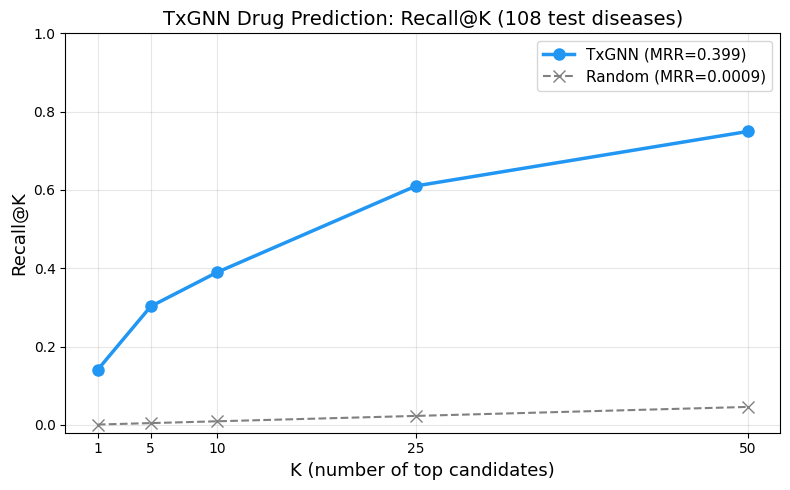

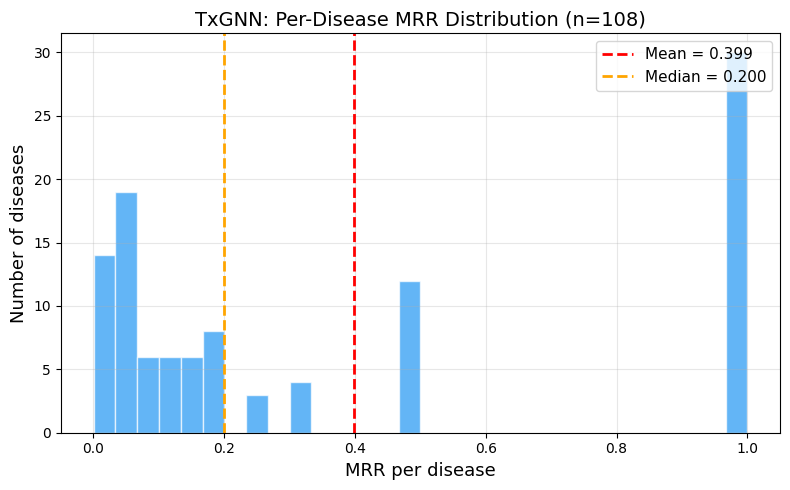

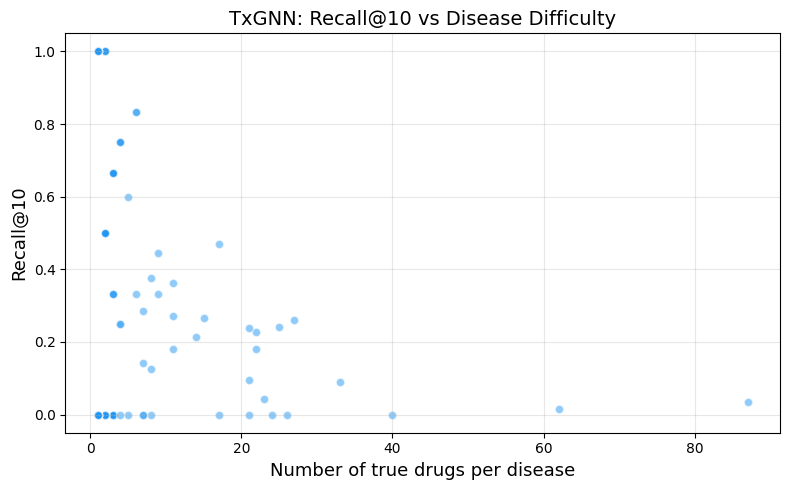

Plots saved to /content/drive/MyDrive/Colab Notebooks/TxGNN_retrained/


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# TxGNN results (from your eval)
# ============================================================
k_values = [1, 5, 10, 25, 50]
txgnn_recalls = [0.1410, 0.3028, 0.3897, 0.6103, 0.7493]
txgnn_mrr = 0.3986

# Random baseline
n_drugs = 7957
avg_pos = 7.3
random_recalls = [k * avg_pos / n_drugs for k in k_values]
random_mrr = avg_pos / n_drugs  # ~0.0009

# ============================================================
# Plot 1: Recall@K curve
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, txgnn_recalls, 'o-', color='#2196F3', linewidth=2.5,
        markersize=8, label=f'TxGNN (MRR={txgnn_mrr:.3f})')
ax.plot(k_values, random_recalls, 'x--', color='gray', linewidth=1.5,
        markersize=8, label=f'Random (MRR={random_mrr:.4f})')

ax.set_xlabel('K (number of top candidates)', fontsize=13)
ax.set_ylabel('Recall@K', fontsize=13)
ax.set_title('TxGNN Drug Prediction: Recall@K (108 test diseases)', fontsize=14)
ax.legend(fontsize=11)
ax.set_xticks(k_values)
ax.set_ylim(-0.02, 1.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir + 'recall_at_k.png', dpi=150)
plt.show()

# ============================================================
# Plot 2: Per-disease MRR distribution
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(mrrs, bins=30, color='#2196F3', alpha=0.7, edgecolor='white')
ax.axvline(np.mean(mrrs), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {np.mean(mrrs):.3f}')
ax.axvline(np.median(mrrs), color='orange', linestyle='--', linewidth=2,
           label=f'Median = {np.median(mrrs):.3f}')
ax.set_xlabel('MRR per disease', fontsize=13)
ax.set_ylabel('Number of diseases', fontsize=13)
ax.set_title('TxGNN: Per-Disease MRR Distribution (n=108)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir + 'mrr_distribution.png', dpi=150)
plt.show()

# ============================================================
# Plot 3: Per-disease Recall@10 vs number of true drugs
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
recall10_list = [recalls[10][i] for i in range(len(mrrs))]  # from your eval
ax.scatter(n_pos_list, recall10_list, alpha=0.5, color='#2196F3', edgecolors='white')
ax.set_xlabel('Number of true drugs per disease', fontsize=13)
ax.set_ylabel('Recall@10', fontsize=13)
ax.set_title('TxGNN: Recall@10 vs Disease Difficulty', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir + 'recall10_vs_npos.png', dpi=150)
plt.show()

print(f"Plots saved to {save_dir}")

In [ ]:
import numpy as np

# Actual random baseline simulation
np.random.seed(42)
k_values = [1, 5, 10, 25, 50]
n_trials = 10000

mrrs_random = []
recalls_random = {k: [] for k in k_values}

for key in result['prediction']:
    labels_dict = result['label'][key]
    drug_ids = list(labels_dict.keys())
    labels = np.array([labels_dict[d] for d in drug_ids])
    n_pos = int(np.sum(labels == 1))
    if n_pos == 0:
        continue

    # Average over many random shuffles
    disease_mrrs = []
    disease_recalls = {k: [] for k in k_values}

    for _ in range(100):
        perm = np.random.permutation(len(labels))
        shuffled = labels[perm]

        first_pos = np.where(shuffled == 1)[0]
        disease_mrrs.append(1.0 / (first_pos[0] + 1) if len(first_pos) > 0 else 0.0)

        for k in k_values:
            disease_recalls[k].append(np.sum(shuffled[:k]) / n_pos)

    mrrs_random.append(np.mean(disease_mrrs))
    for k in k_values:
        recalls_random[k].append(np.mean(disease_recalls[k]))

print("=== Empirical Random Baseline ===")
print(f"Diseases: {len(mrrs_random)}")
print(f"\n{'Metric':<15} {'Mean':>8}")
print("-" * 25)
print(f"{'MRR':<15} {np.mean(mrrs_random):>8.4f}")
for k in k_values:
    print(f"{'Recall@'+str(k):<15} {np.mean(recalls_random[k]):>8.4f}")

=== Empirical Random Baseline ===
Diseases: 108

Metric              Mean
-------------------------
MRR               0.0062
Recall@1          0.0001
Recall@5          0.0006
Recall@10         0.0014
Recall@25         0.0030
Recall@50         0.0059


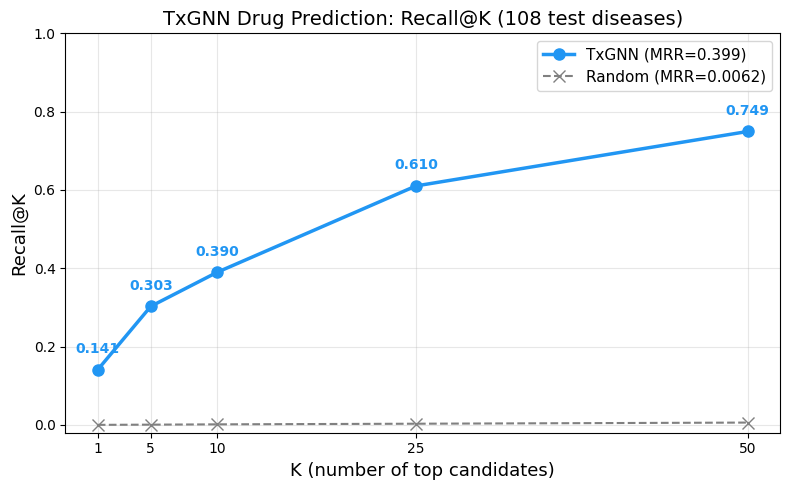

Plot saved!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# TxGNN results
k_values = [1, 5, 10, 25, 50]
txgnn_recalls = [0.1410, 0.3028, 0.3897, 0.6103, 0.7493]
txgnn_mrr = 0.3986

# Empirical random baseline
random_recalls = [0.0001, 0.0006, 0.0014, 0.0030, 0.0059]
random_mrr = 0.0062

# Recall@K curve with labels
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, txgnn_recalls, 'o-', color='#2196F3', linewidth=2.5,
        markersize=8, label=f'TxGNN (MRR={txgnn_mrr:.3f})')
ax.plot(k_values, random_recalls, 'x--', color='gray', linewidth=1.5,
        markersize=8, label=f'Random (MRR={random_mrr:.4f})')

# Add numbers above TxGNN nodes
for k, r in zip(k_values, txgnn_recalls):
    ax.annotate(f'{r:.3f}', (k, r), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=10, fontweight='bold', color='#2196F3')

ax.set_xlabel('K (number of top candidates)', fontsize=13)
ax.set_ylabel('Recall@K', fontsize=13)
ax.set_title('TxGNN Drug Prediction: Recall@K (108 test diseases)', fontsize=14)
ax.legend(fontsize=11)
ax.set_xticks(k_values)
ax.set_ylim(-0.02, 1.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(save_dir + 'recall_at_k.png', dpi=150)
plt.show()

print("Plot saved!")